# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Saving the model
import pickle

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Create Dataset

In [2]:
np.random.seed(42)
data = {
    'CustomerID': np.arange(1, 101),
    'Age': np.random.randint(18, 65, size=100),
    'Average_Spend': np.random.uniform(5, 50, size=100),
    'Visits_per_Week': np.random.uniform(1, 7, size=100),
    'Promotion_Interest': np.random.randint(1, 11, size=100)
}

# Convert to a DataFrame
df = pd.DataFrame(data)
df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest
0,1,56,18.206968,5.266897,2
1,2,46,5.633592,5.857006,9
2,3,32,13.947908,3.091996,8
3,4,60,37.010388,1.577059,10
4,5,25,40.557899,6.643140,7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          100 non-null    int64  
 1   Age                 100 non-null    int32  
 2   Average_Spend       100 non-null    float64
 3   Visits_per_Week     100 non-null    float64
 4   Promotion_Interest  100 non-null    int32  
dtypes: float64(2), int32(2), int64(1)
memory usage: 3.3 KB


In [4]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,100.0,50.500000,29.011492,1.000000,25.750000,50.500000,75.250000,100.000000
Age,100.0,40.880000,13.990820,18.000000,30.500000,41.000000,53.250000,64.000000
Average_Spend,100.0,26.657764,12.254064,5.023417,16.347001,25.853792,36.273547,49.898322
Visits_per_Week,100.0,4.277752,1.666998,1.108452,2.833682,4.177598,5.748284,6.977522
Promotion_Interest,100.0,5.850000,2.952058,1.000000,4.000000,6.000000,8.250000,10.000000


In [5]:
df.columns

Index(['CustomerID', 'Age', 'Average_Spend', 'Visits_per_Week',
       'Promotion_Interest'],
      dtype='object')

# Apply Kmeans Clustering for Customer Segmentation into Three(3) Groups

In [6]:
# Prepare the data for clustering
X = df[['Age', 'Average_Spend', 'Visits_per_Week', 'Promotion_Interest']]

In [7]:
# Elbow method to find optimal number of clusters
sse = []
k_range = range(1, 11)  # range from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

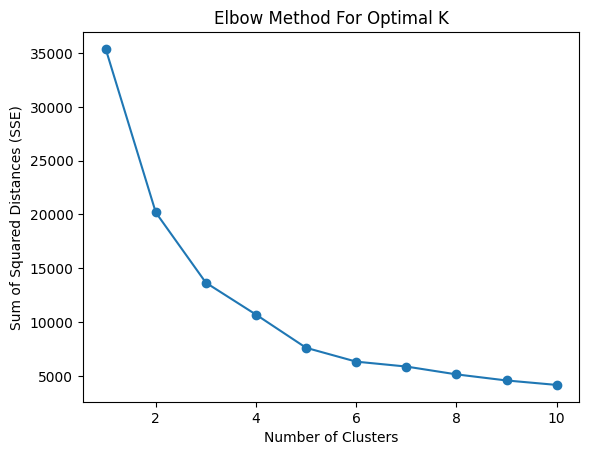

In [8]:
# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [9]:
# Cluster based on 'Age', 'Average_Spend', 'Visits_per_Week', and 'Promotion_Interest'
features = df[['Age', 'Average_Spend', 'Visits_per_Week', 'Promotion_Interest']]

In [10]:
# Initialization of KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

In [11]:
# Fit the model
df['Cluster'] = kmeans.fit_predict(features)


In [12]:
# Rename clusters to 'Daily', 'Promotion', 'Weekend'
cluster_names = {0: 'Daily', 1: 'Promotion', 2: 'Weekend'}
df['Customer Group'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest,Cluster,Customer Group
0,1,56,18.206968,5.266897,2,2,Weekend
1,2,46,5.633592,5.857006,9,2,Weekend
2,3,32,13.947908,3.091996,8,2,Weekend
3,4,60,37.010388,1.577059,10,0,Daily
4,5,25,40.557899,6.643140,7,1,Promotion


# Visualize the clusters using Age and Average Spend (2D Plot)

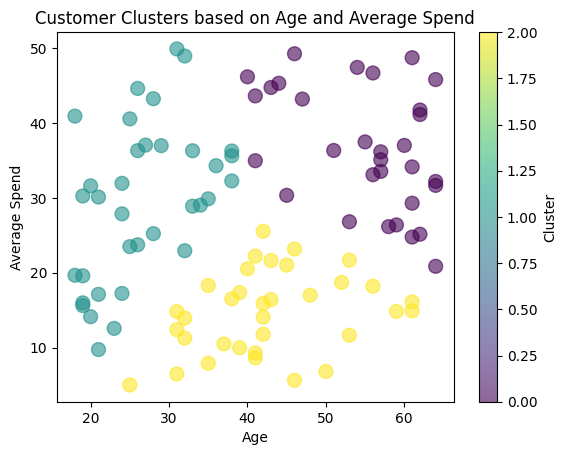

In [13]:
plt.scatter(df['Age'], df['Average_Spend'], c=df['Cluster'], cmap='viridis', marker='o', s=100, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Average Spend')
plt.title('Customer Clusters based on Age and Average Spend')
plt.colorbar(label='Cluster')
plt.show()

# Clustering performance Evaluation with the help of Silhouette score

In [14]:
silhouette_avg = silhouette_score(features, df['Cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.37


# Save the model

In [15]:
pickle.dump(kmeans,open("kmeans.pkl",'wb'))

# Prediction of the cluster of a new customer

In [16]:
def clustering(age,avg_spend,visit_per_week, promotion_interest):
    new_customer = np.array([[age,avg_spend,visit_per_week, promotion_interest]])
    predicted_cluster = kmeans.predict(new_customer)

    if predicted_cluster[0]==0:
      print("Daily")
    elif predicted_cluster[0]==1:
      print("Weekend")
    else:
      print("Promotion")

In [17]:
# test 1
age = 40
avg_spend = 30
visit_per_week= 4
promotion_interest= 7


predicted_cluster = clustering(age, avg_spend,visit_per_week,promotion_interest)
print(f'New Customer assigned to Cluster: {predicted_cluster}')

Weekend
New Customer assigned to Cluster: None


In [18]:
# test 2
age = 40
avg_spend = 10
visit_per_week= 1
promotion_interest= 0


predicted_cluster = clustering(age, avg_spend,visit_per_week,promotion_interest)
print(f'New Customer assigned to Cluster: {predicted_cluster}')

Promotion
New Customer assigned to Cluster: None
